### ============================================================================
### MULTIMODAL LATE FUSION (FEATURE-LEVEL) FOR BRAIN TUMOR DETECTION
### ============================================================================
### Author: Jeisson Parra Prieto 
### Description:
####   - Loads pre-trained MRI (two-stage) and CT (correlation) models.
####  - Extracts features from the penultimate layer of each model.
####   - Concatenates features and trains a fusion classifier on paired data.
####   - Evaluates performance against unimodal baselines.
####   - Generates Grad-CAM heatmaps for interpretability.
### ============================================================================


In [18]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve, auc)
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import re
from math import pi
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
import cv2
import matplotlib.cm as cm

🧠 MULTIMODAL LATE FUSION (FEATURE-LEVEL) PIPELINE
[1/6] Loading pre-trained models...
  - MRI stage-1 loaded.
  - MRI stage-2 loaded.
  - Reconstructing CT model architecture...
  - CT model weights loaded successfully (by name).

[Verification] CT model architecture after weight loading:


/Users/jeissonparra/.pyenv/versions/3.12.12/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "CT_Correlation_Model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ ct_input            │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_extractor     │ (None, 8, 8,      │          0 │ ct_input[0][0]    │
│ (Lambda)            │ 3136)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_flat        │ (None, 64, 3136)  │          0 │ patch_extractor[… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_image       │ (None, 64, 28,    │          0 │ reshape_flat[0][… │
│ (Reshape)           │ 28, 4)            │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_e… │ (None, 64, 128)   │    421,472 │ reshape_image[0]… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ correlation_layer   │ (None, 64, 64)    │          0 │ time_distributed… │
│ (CorrelationLayer)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ guided_features     │ (None, 64, 128)   │          0 │ correlation_laye… │
│ (Dot)               │                   │            │ time_distributed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ combined_features   │ (None, 64, 256)   │          0 │ time_distributed… │
│ (Concatenate)       │                   │            │ guided_features[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_pool         │ (None, 256)       │          0 │ combined_feature… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fc1 (Dense)         │ (None, 256)       │     65,792 │ global_pool[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout1 (Dropout)  │ (None, 256)       │          0 │ fc1[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fc2 (Dense)         │ (None, 32)        │      8,224 │ dropout1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 2)         │         66 │ fc2[0][0]         │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 495,554 (1.89 MB)

...

 Trainable params: 45,378 (177.26 KB)

 Non-trainable params: 2,237,152 (8.53 MB)

[2/6] Preparing paired data generators...
[PairedGenerator] Found 3195 pairs for split 'train'
[PairedGenerator] Found 309 pairs for split 'val'
[PairedGenerator] Found 330 pairs for split 'test'
[3/6] Training fusion model...
Epoch 1/50


/Users/jeissonparra/.pyenv/versions/3.12.12/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


200/200 ━━━━━━━━━━━━━━━━━━━━ 13s 43ms/step - accuracy: 0.5433 - loss: 1.7837 - val_accuracy: 0.6440 - val_loss: 0.7377 - learning_rate: 1.0000e-04
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.5596 - loss: 1.2283 - val_accuracy: 0.6343 - val_loss: 0.7186 - learning_rate: 1.0000e-04
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.5656 - loss: 1.0134 - val_accuracy: 0.6505 - val_loss: 0.6467 - learning_rate: 1.0000e-04
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.5784 - loss: 0.9176 - val_accuracy: 0.6149 - val_loss: 0.6853 - learning_rate: 1.0000e-04
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.5865 - loss: 0.8021 - val_accuracy: 0.6246 - val_loss: 0.6772 - learning_rate: 1.0000e-04


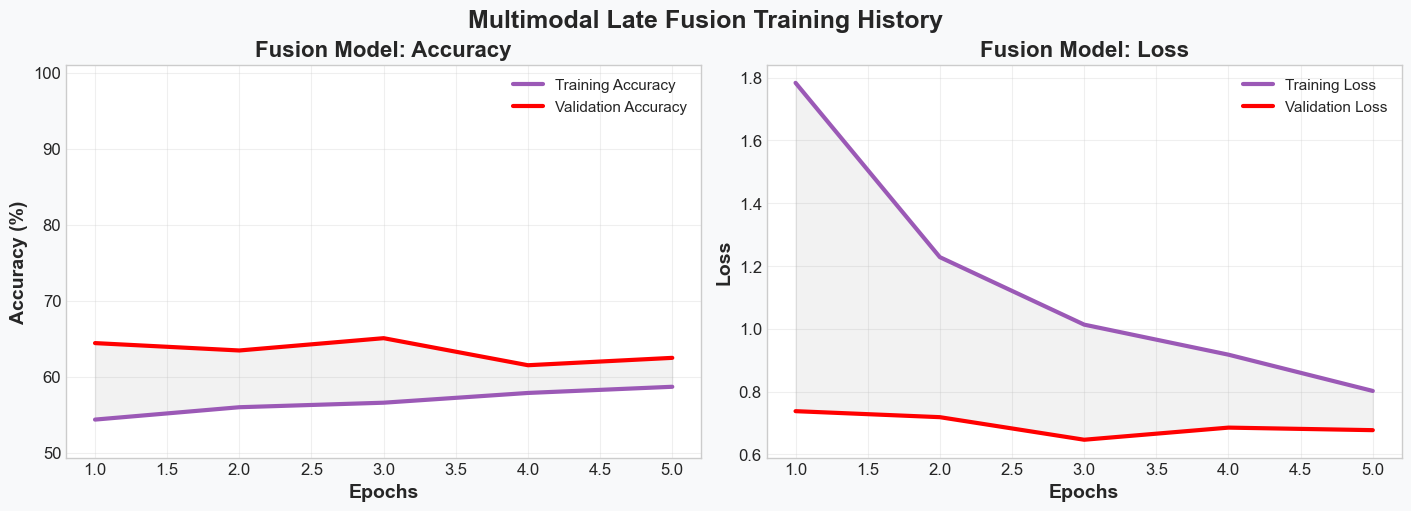

[4/6] Evaluating fusion model on test set...


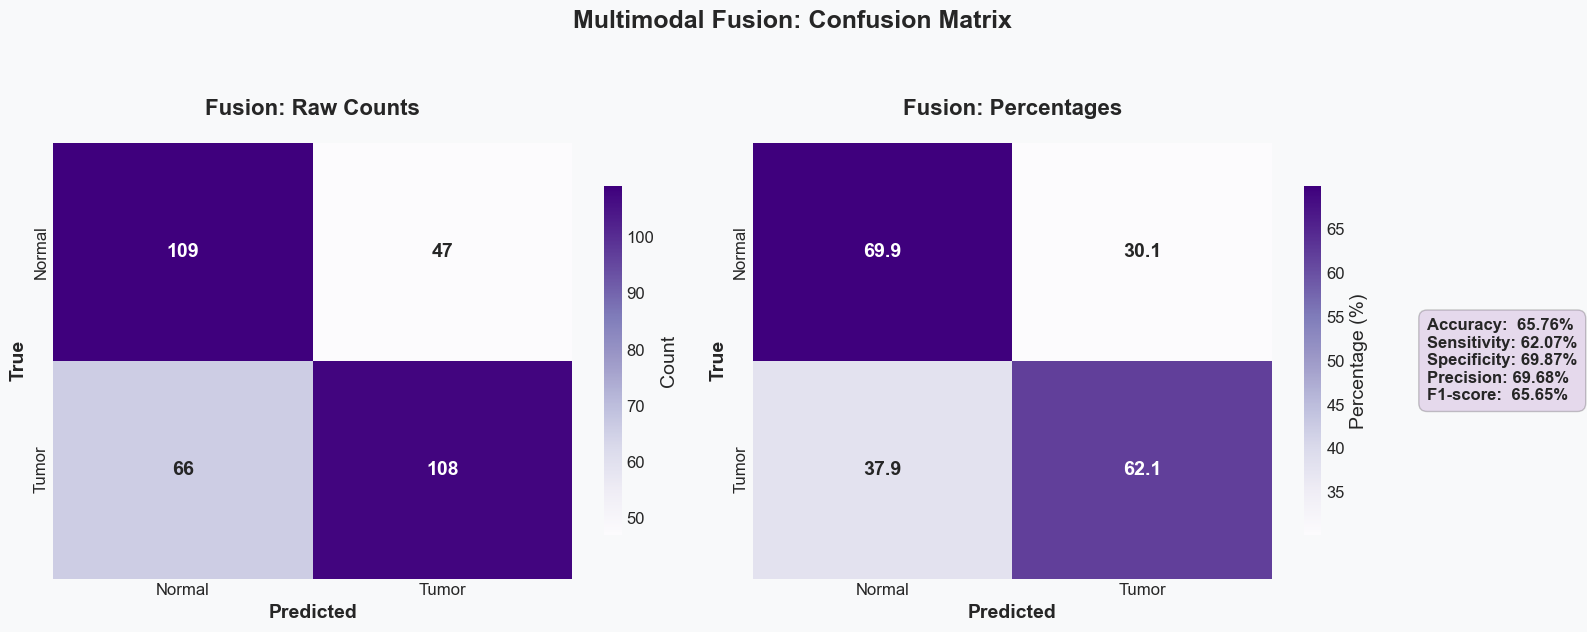

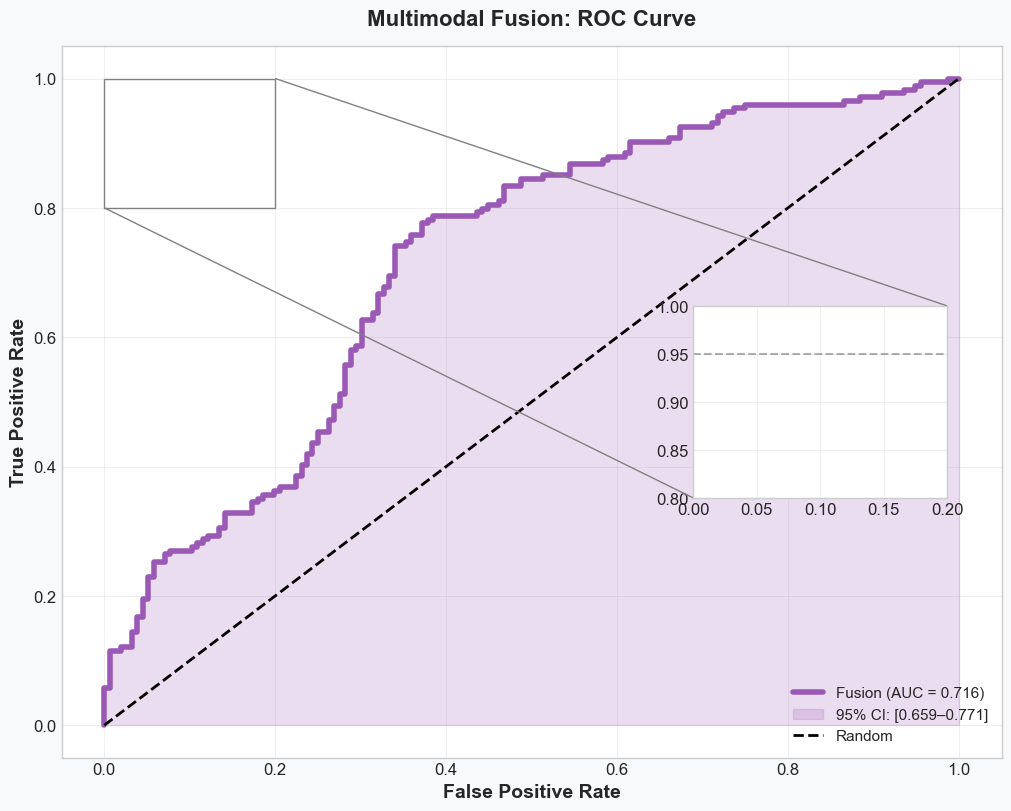

[5/6] Loading unimodal baseline scores...
MRI scores: [98.23321554770318, 98.48389134554643, 98.0503144654088, 98.26662464544594, 99.79026003790929]
CT scores: [75.15151515151514, 73.46938775510205, 82.75862068965517, 77.83783783783784, 81.79339817270852]
Fusion scores: [65.75757575757576, 69.6774193548387, 62.06896551724138, 65.65349544072949, 71.570144414972]


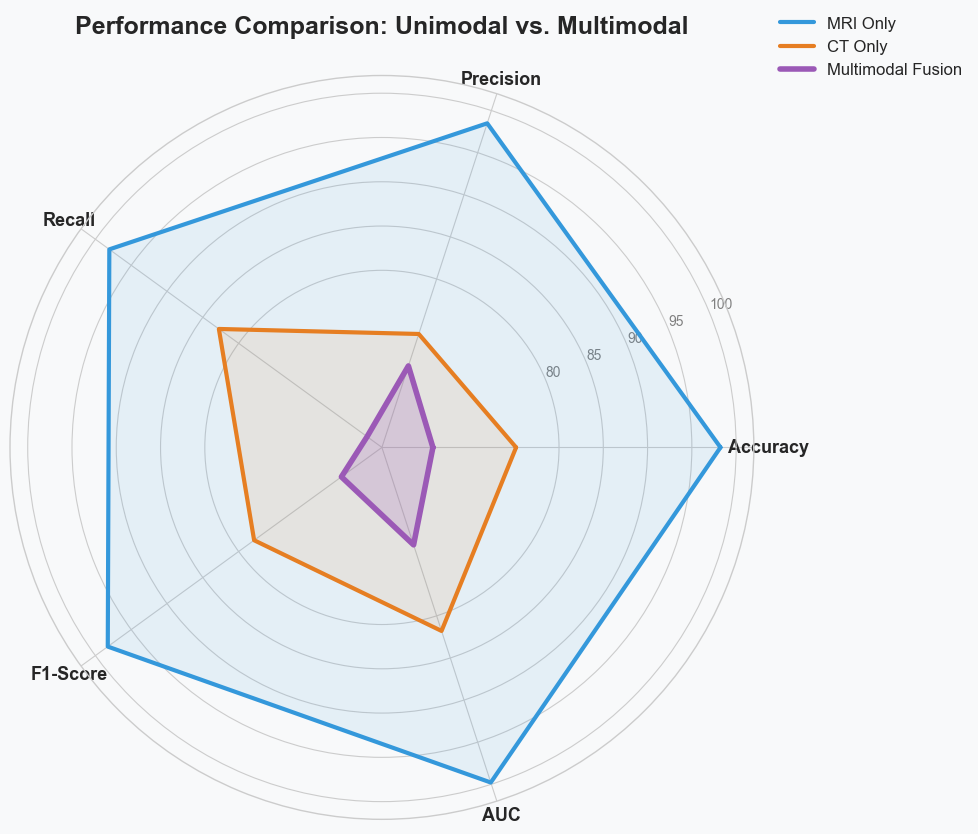


CLASSIFICATION REPORT - FUSION MODEL
              precision    recall  f1-score   support

      Normal       0.62      0.70      0.66       156
       Tumor       0.70      0.62      0.66       174

    accuracy                           0.66       330
   macro avg       0.66      0.66      0.66       330
weighted avg       0.66      0.66      0.66       330


 MULTIMODAL FUSION PIPELINE COMPLETED
All figures saved to: ./Results/Fusion_figures


In [19]:
# ============================================================================
# MULTIMODAL LATE FUSION (FEATURE-LEVEL) FOR BRAIN TUMOR DETECTION
# ============================================================================
# This script reconstructs the CT model from code (to avoid Lambda serialisation issues)
# and loads its pre‑trained weights. It then builds a fusion model on top of
# features from MRI stage‑1 and CT models.
# ============================================================================

import os
import re
import pickle
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve, auc)
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from math import pi
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
import cv2

# ============================================================================
# CONFIGURATION
# ============================================================================

CONFIG = {
    # Paths to pre-trained models
    'MRI_STAGE1_PATH': './Saved_models/MRI_stage1_binary_model.keras',
    'MRI_STAGE2_PATH': './Saved_models/MRI_stage2_multiclass_model.keras',
    'CT_MODEL_PATH': './Saved_models/ct_correlation_model.keras',   # weights file (old version)

    # Data directories (must contain train/val/test subfolders with MRI and CT)
    'MRI_DATA_ROOT': '/Users/jeissonparra/Documents/Master_s Degree Florida International University/Data Science & AI/Spring - 2026/Capstone/Datasets/Balanced_Multimodal/MRI',
    'CT_DATA_ROOT': '/Users/jeissonparra/Documents/Master_s Degree Florida International University/Data Science & AI/Spring - 2026/Capstone/Datasets/Balanced_Multimodal/CT',

    # Fusion model parameters
    'FUSION_INPUT_SHAPE_MRI': (128, 128, 4),
    'FUSION_INPUT_SHAPE_CT': (224, 224, 4),
    'NUM_CLASSES': 2,                # binary: normal vs tumor
    'BATCH_SIZE': 16,
    'EPOCHS': 50,
    'LEARNING_RATE': 1e-4,

    # Output paths
    'FUSION_MODEL_SAVE_PATH': './Saved_models/fusion_model.keras',
    'FIGURE_PATH': './Results/Fusion_figures',
    'RESULTS_PATH': './Results',
}

CLASS_NAMES = ['Normal', 'Tumor']
STAGE2_CLASS_NAMES = ['Meningioma', 'Glioma', 'Pituitary']

COLORS = {
    'mri': '#3498DB',
    'ct': '#E67E22',
    'multimodal': '#9B59B6',
    'normal': '#2ECC71',
    'tumor': '#E74C3C',
    'background': '#F8F9FA',
    'meningioma': '#3498DB',
    'glioma': '#9B59B6',
    'pituitary': '#E67E22',
}

os.makedirs(CONFIG['FIGURE_PATH'], exist_ok=True)
os.makedirs(CONFIG['RESULTS_PATH'], exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['legend.fontsize'] = 11

# ============================================================================
# CT MODEL ARCHITECTURE (reconstruction for weight loading)
# ============================================================================

class CorrelationLayer(layers.Layer):
    def call(self, inputs):
        return tf.matmul(inputs, inputs, transpose_b=True)

def build_ct_correlation_model(input_shape, patch_size, num_patches, num_classes):
    inputs = layers.Input(shape=input_shape, name="ct_input")

    # Patch extraction (with explicit output_shape for safety)
    extract_patches = layers.Lambda(
        lambda x: tf.image.extract_patches(
            images=x,
            sizes=[1, patch_size, patch_size, 1],
            strides=[1, patch_size, patch_size, 1],
            rates=[1, 1, 1, 1],
            padding='VALID'
        ),
        output_shape=lambda s: (s[0], 
                                input_shape[0] // patch_size, 
                                input_shape[1] // patch_size, 
                                patch_size * patch_size * input_shape[2]),
        name="patch_extractor"
    )
    patches = extract_patches(inputs)                     # (batch, 8, 8, 28*28*4)

    patches_reshaped = layers.Reshape((num_patches, -1), name="reshape_flat")(patches)  # (batch, 64, 3136)
    patches_img = layers.Reshape((num_patches, patch_size, patch_size, input_shape[-1]), 
                                  name="reshape_image")(patches_reshaped)

    # Shared CNN encoder with explicit names
    encoder = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                      input_shape=(patch_size, patch_size, input_shape[-1]),
                      name="enc_conv1"),
        layers.MaxPooling2D((2, 2), name="enc_pool1"),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same', name="enc_conv2"),
        layers.MaxPooling2D((2, 2), name="enc_pool2"),
        layers.Flatten(name="enc_flatten"),
        layers.Dense(128, activation='relu', name="enc_dense"),
        layers.LayerNormalization(name="enc_layernorm")
    ], name="shared_encoder")

    patch_features = layers.TimeDistributed(encoder, name="time_distributed_encoder")(patches_img)  # (batch, 64, 128)

    correlation_matrix = CorrelationLayer(name="correlation_layer")(patch_features)  # (batch, 64, 64)

    guided_features = layers.Dot(axes=(2, 1), name="guided_features")([correlation_matrix, patch_features])

    combined_features = layers.Concatenate(axis=-1, name="combined_features")([patch_features, guided_features])

    pooled_features = layers.GlobalAveragePooling1D(name="global_pool")(combined_features)  # (batch, 256)

    # Classification head (with explicit names)
    x = layers.Dense(256, activation='relu', name="fc1")(pooled_features)
    x = layers.Dropout(0.5, name="dropout1")(x)
    x = layers.Dense(32, activation='relu', name="fc2")(x)
    outputs = layers.Dense(num_classes, activation='softmax', name="output")(x)

    model = models.Model(inputs=inputs, outputs=outputs, name="CT_Correlation_Model")
    return model

# ============================================================================
# PAIRED DATA GENERATOR (for fusion)
# ============================================================================

class PairedMultimodalGenerator(tf.keras.utils.Sequence):
    """
    Generates batches of (MRI, CT) pairs with the same patient ID.
    Assumes filenames follow the pattern: <modality>_<label>_<patientID>_<tumorType?>_processed.npy
    For normal images, tumorType may be absent.
    """
    def __init__(self, mri_root, ct_root, split='train', batch_size=16,
                 mri_shape=(128,128,4), ct_shape=(224,224,4), shuffle=True):
        self.mri_root = os.path.join(mri_root, split)
        self.ct_root = os.path.join(ct_root, split)
        self.split = split                     # store split for error messages
        self.batch_size = batch_size
        self.mri_shape = mri_shape
        self.ct_shape = ct_shape
        self.shuffle = shuffle
        self.pairs = []          # list of (mri_path, ct_path, label, patient_id)
        self._build_pairs()
        self.on_epoch_end()

    def _extract_patient_id(self, filename):
        """Extract patient ID from filename (e.g., 'MRI_tumor_0034_2_processed.npy' → '0034')"""
        base = filename.replace('.npy', '')
        parts = base.split('_')
        if len(parts) >= 3 and parts[2].isdigit():
            return parts[2]
        numbers = re.findall(r'\d+', base)
        return numbers[0] if numbers else None

    def _build_pairs(self):
        """Scan both directories and match files by patient ID."""
        mri_files = {}
        for root, _, files in os.walk(self.mri_root):
            for f in files:
                if f.endswith('.npy'):
                    patient_id = self._extract_patient_id(f)
                    if patient_id:
                        mri_files[patient_id] = os.path.join(root, f)

        for root, _, files in os.walk(self.ct_root):
            for f in files:
                if f.endswith('.npy'):
                    patient_id = self._extract_patient_id(f)
                    if patient_id and patient_id in mri_files:
                        mri_path = mri_files[patient_id]
                        ct_path = os.path.join(root, f)
                        # Determine label (0=normal, 1=tumor) from folder name or filename
                        if 'normal' in ct_path.lower():
                            label = 0
                        elif 'tumor' in ct_path.lower():
                            label = 1
                        else:
                            label = 1 if 'tumor' in f.lower() else 0
                        self.pairs.append((mri_path, ct_path, label, patient_id))

        if len(self.pairs) == 0:
            raise RuntimeError("No paired MRI-CT files found. Check your directory structure and patient ID extraction logic.")
        print(f"[PairedGenerator] Found {len(self.pairs)} pairs for split '{self.split}'")

    def __len__(self):
        return int(np.ceil(len(self.pairs) / self.batch_size))

    def __getitem__(self, index):
        start = index * self.batch_size
        end = min((index + 1) * self.batch_size, len(self.pairs))
        batch_indices = self.indexes[start:end]
        batch_pairs = [self.pairs[i] for i in batch_indices]

        mri_batch = np.zeros((len(batch_pairs), *self.mri_shape), dtype=np.float32)
        ct_batch = np.zeros((len(batch_pairs), *self.ct_shape), dtype=np.float32)
        labels = []

        for i, (mri_path, ct_path, label, _) in enumerate(batch_pairs):
            mri_img = np.load(mri_path).astype(np.float32)
            ct_img = np.load(ct_path).astype(np.float32)

            if mri_img.shape[:2] != self.mri_shape[:2]:
                mri_img = tf.image.resize(mri_img, self.mri_shape[:2]).numpy()
            if ct_img.shape[:2] != self.ct_shape[:2]:
                ct_img = tf.image.resize(ct_img, self.ct_shape[:2]).numpy()

            mri_batch[i] = mri_img
            ct_batch[i] = ct_img
            labels.append(label)

        labels = to_categorical(labels, num_classes=2)
        return (mri_batch, ct_batch), labels

    def on_epoch_end(self):
        self.indexes = np.arange(len(self.pairs))
        if self.shuffle:
            np.random.shuffle(self.indexes)

# ============================================================================
# LOAD PRE-TRAINED MODELS AND CREATE FEATURE EXTRACTORS
# ============================================================================

def load_pretrained_models():
    """Load MRI stage-1, stage-2, and reconstruct CT model with weights."""
    print("[1/6] Loading pre-trained models...")

    # MRI models (standard Keras – load normally)
    mri_stage1 = tf.keras.models.load_model(CONFIG['MRI_STAGE1_PATH'])
    print("  - MRI stage-1 loaded.")

    mri_stage2 = tf.keras.models.load_model(CONFIG['MRI_STAGE2_PATH'])
    print("  - MRI stage-2 loaded.")

    # CT model: reconstruct and load weights by name
    print("  - Reconstructing CT model architecture...")
    ct_model = build_ct_correlation_model(
        input_shape=CONFIG['FUSION_INPUT_SHAPE_CT'],
        patch_size=28,          # must match training
        num_patches=64,
        num_classes=2
    )

    # Load weights using by_name=True (layer names must match)
    ct_model.load_weights(CONFIG['CT_MODEL_PATH'])
    print("  - CT model weights loaded successfully (by name).")

    print("\n[Verification] CT model architecture after weight loading:")
    ct_model.summary()
    print(f"  - Total parameters in CT model: {ct_model.count_params():,}")

    return mri_stage1, mri_stage2, ct_model

def create_feature_extractors(mri_stage1, ct_model):
    """
    Create models that output features from the penultimate layer.
    For MRI stage-1: layer 'fc3' (Dense(256)).
    For CT model: penultimate Dense layer (index -2, Dense(32)).
    """
    mri_feature = models.Model(
        inputs=mri_stage1.input,
        outputs=mri_stage1.get_layer('fc3').output,
        name="MRI_feature_extractor"
    )
    mri_feature.trainable = False
    print("  - MRI feature extractor created (output shape: 256).")

    ct_feature = models.Model(
        inputs=ct_model.input,
        outputs=ct_model.layers[-2].output,   # penultimate layer (Dense(32))
        name="CT_feature_extractor"
    )
    ct_feature.trainable = False
    print("  - CT feature extractor created (output shape: 32).")

    return mri_feature, ct_feature

# ============================================================================
# BUILD FUSION MODEL
# ============================================================================

def build_fusion_model(mri_feature, ct_feature):
    """Concatenate features and add dense layers for binary classification."""
    mri_input = layers.Input(shape=CONFIG['FUSION_INPUT_SHAPE_MRI'], name="MRI_input")
    ct_input = layers.Input(shape=CONFIG['FUSION_INPUT_SHAPE_CT'], name="CT_input")

    mri_feat = mri_feature(mri_input)      # (256,)
    ct_feat = ct_feature(ct_input)          # (32,)

    concat = layers.Concatenate(name="concat_features")([mri_feat, ct_feat])  # (288,)

    x = layers.Dense(128, activation='relu', name="fc_joint_1")(concat)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(64, activation='relu', name="fc_joint_2")(x)
    x = layers.Dropout(0.3)(x)
    output = layers.Dense(2, activation='softmax', name="output")(x)

    model = models.Model(inputs=[mri_input, ct_input], outputs=output, name="Multimodal_Fusion")
    return model

# ============================================================================
# TRAINING AND EVALUATION UTILITIES
# ============================================================================

def plot_fusion_training_curves(history):
    acc = np.array(history.history['accuracy']) * 100
    val_acc = np.array(history.history['val_accuracy']) * 100
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = np.arange(1, len(acc)+1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
    fig.patch.set_facecolor(COLORS['background'])

    ax1.plot(epochs, acc, color=COLORS['multimodal'], label='Training Accuracy', lw=3)
    ax1.plot(epochs, val_acc, color='red', label='Validation Accuracy', lw=3)
    ax1.fill_between(epochs, acc, val_acc, alpha=0.1, color='gray')
    ax1.set_xlabel('Epochs', fontweight='bold')
    ax1.set_ylabel('Accuracy (%)', fontweight='bold')
    ax1.set_title('Fusion Model: Accuracy', fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    ax1.set_ylim([min(acc.min(), val_acc.min())-5, 101])

    ax2.plot(epochs, loss, color=COLORS['multimodal'], label='Training Loss', lw=3)
    ax2.plot(epochs, val_loss, color='red', label='Validation Loss', lw=3)
    ax2.fill_between(epochs, loss, val_loss, alpha=0.1, color='gray')
    ax2.set_xlabel('Epochs', fontweight='bold')
    ax2.set_ylabel('Loss', fontweight='bold')
    ax2.set_title('Fusion Model: Loss', fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.legend()

    plt.suptitle('Multimodal Late Fusion Training History', fontsize=18, fontweight='bold')
    plt.savefig(os.path.join(CONFIG['FIGURE_PATH'], 'fusion_training_curves.png'), dpi=300)
    plt.show()

def plot_fusion_confusion_matrix(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    fig.patch.set_facecolor(COLORS['background'])

    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
                xticklabels=class_names, yticklabels=class_names, ax=ax1,
                cbar_kws={'label': 'Count', 'shrink': 0.8},
                annot_kws={'size': 14, 'weight': 'bold'})
    ax1.set_xlabel('Predicted', fontweight='bold')
    ax1.set_ylabel('True', fontweight='bold')
    ax1.set_title('Fusion: Raw Counts', fontweight='bold', pad=20)

    sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Purples',
                xticklabels=class_names, yticklabels=class_names, ax=ax2,
                cbar_kws={'label': 'Percentage (%)', 'shrink': 0.8},
                annot_kws={'size': 14, 'weight': 'bold'})
    ax2.set_xlabel('Predicted', fontweight='bold')
    ax2.set_ylabel('True', fontweight='bold')
    ax2.set_title('Fusion: Percentages', fontweight='bold', pad=20)

    tn, fp, fn, tp = cm.ravel()
    acc = (tp+tn)/np.sum(cm)
    sens = tp/(tp+fn) if (tp+fn)>0 else 0
    spec = tn/(tn+fp) if (tn+fp)>0 else 0
    prec = tp/(tp+fp) if (tp+fp)>0 else 0
    f1 = 2*(prec*sens)/(prec+sens) if (prec+sens)>0 else 0

    textstr = (f'Accuracy:  {acc*100:.2f}%\n'
               f'Sensitivity: {sens*100:.2f}%\n'
               f'Specificity: {spec*100:.2f}%\n'
               f'Precision: {prec*100:.2f}%\n'
               f'F1-score:  {f1*100:.2f}%')
    ax2.text(1.3, 0.5, textstr, transform=ax2.transAxes,
             fontsize=12, fontweight='bold', verticalalignment='center',
             bbox=dict(boxstyle="round,pad=0.5", facecolor=COLORS['multimodal'], alpha=0.2))

    plt.suptitle('Multimodal Fusion: Confusion Matrix', fontsize=18, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.savefig(os.path.join(CONFIG['FIGURE_PATH'], 'fusion_confusion_matrix.png'), dpi=300)
    plt.show()
    return acc, sens, spec, prec, f1

def plot_fusion_roc_curve(y_true, y_pred_proba):
    fpr, tpr, _ = roc_curve(y_true, y_pred_proba[:, 1])
    base_auc = auc(fpr, tpr)

    rng = np.random.RandomState(42)
    n_bootstraps = 1000
    bootstrapped_aucs = []
    y_true_arr = np.array(y_true)
    for _ in range(n_bootstraps):
        indices = rng.randint(0, len(y_true_arr), len(y_true_arr))
        if len(np.unique(y_true_arr[indices])) < 2:
            continue
        score = roc_auc_score(y_true_arr[indices], y_pred_proba[indices, 1])
        bootstrapped_aucs.append(score)
    ci_lower = np.percentile(bootstrapped_aucs, 2.5)
    ci_upper = np.percentile(bootstrapped_aucs, 97.5)

    fig, ax = plt.subplots(figsize=(10, 8), constrained_layout=True)
    fig.patch.set_facecolor(COLORS['background'])

    ax.plot(fpr, tpr, color=COLORS['multimodal'], lw=4,
            label=f'Fusion (AUC = {base_auc:.3f})')
    ax.fill_between(fpr, tpr, alpha=0.2, color=COLORS['multimodal'],
                    label=f'95% CI: [{ci_lower:.3f}–{ci_upper:.3f}]')
    ax.plot([0,1], [0,1], 'k--', lw=2, label='Random')
    ax.set_xlabel('False Positive Rate', fontweight='bold')
    ax.set_ylabel('True Positive Rate', fontweight='bold')
    ax.set_title('Multimodal Fusion: ROC Curve', fontweight='bold', pad=15)
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)

    axins = inset_axes(ax, width="30%", height="30%", loc='center right',
                       bbox_to_anchor=(0.05,0.05,0.9,0.9), bbox_transform=ax.transAxes)
    mask = fpr <= 0.2
    axins.plot(fpr[mask], tpr[mask], color=COLORS['multimodal'], lw=2)
    axins.plot([0,0.2], [0.95,0.95], 'k--', alpha=0.3)
    axins.set_xlim([0,0.2]); axins.set_ylim([0.8,1.0])
    axins.grid(True, alpha=0.3)
    mark_inset(ax, axins, loc1=1, loc2=3, fc="none", ec="gray")

    plt.savefig(os.path.join(CONFIG['FIGURE_PATH'], 'fusion_roc_curve.png'), dpi=300)
    plt.show()
    return base_auc, ci_lower, ci_upper

def plot_radar_chart(mri_scores, ct_scores, fusion_scores):
    categories = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC']
    N = len(categories)
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(10,10), subplot_kw=dict(polar=True))
    fig.patch.set_facecolor(COLORS['background'])
    ax.set_facecolor(COLORS['background'])

    mri_vals = mri_scores + mri_scores[:1]
    ct_vals = ct_scores + ct_scores[:1]
    fusion_vals = fusion_scores + fusion_scores[:1]

    ax.plot(angles, mri_vals, linewidth=3, color=COLORS['mri'], label='MRI Only')
    ax.fill(angles, mri_vals, color=COLORS['mri'], alpha=0.1)
    ax.plot(angles, ct_vals, linewidth=3, color=COLORS['ct'], label='CT Only')
    ax.fill(angles, ct_vals, color=COLORS['ct'], alpha=0.1)
    ax.plot(angles, fusion_vals, linewidth=4, color=COLORS['multimodal'], label='Multimodal Fusion')
    ax.fill(angles, fusion_vals, color=COLORS['multimodal'], alpha=0.2)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, size=13, fontweight='bold')
    ax.set_ylim(60, 102)
    ax.set_yticks([80,85,90,95,100])
    ax.set_yticklabels(['80','85','90','95','100'], color='grey', size=10)
    ax.set_title('Performance Comparison: Unimodal vs. Multimodal', size=18, fontweight='bold', pad=30)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3,1.1), fontsize=12)

    plt.tight_layout()
    plt.savefig(os.path.join(CONFIG['FIGURE_PATH'], 'radar_chart.png'), dpi=300)
    plt.savefig(os.path.join(CONFIG['FIGURE_PATH'], 'radar_chart.pdf'))
    plt.show()



# ============================================================================
# MAIN PIPELINE
# ============================================================================

def run_fusion_pipeline():
    print("="*70)
    print("🧠 MULTIMODAL LATE FUSION (FEATURE-LEVEL) PIPELINE")
    print("="*70)

    # 1. Load pre-trained models
    mri_stage1, mri_stage2, ct_model = load_pretrained_models()

    # 2. Create feature extractors
    mri_feature, ct_feature = create_feature_extractors(mri_stage1, ct_model)

    # 3. Build fusion model
    fusion_model = build_fusion_model(mri_feature, ct_feature)
    fusion_model.compile(
        optimizer=optimizers.Adam(learning_rate=CONFIG['LEARNING_RATE']),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    fusion_model.summary()

    # 4. Prepare paired data generators
    print("[2/6] Preparing paired data generators...")
    train_gen = PairedMultimodalGenerator(CONFIG['MRI_DATA_ROOT'], CONFIG['CT_DATA_ROOT'], split='train',batch_size=CONFIG['BATCH_SIZE'], mri_shape=CONFIG['FUSION_INPUT_SHAPE_MRI'],ct_shape=CONFIG['FUSION_INPUT_SHAPE_CT'])
    val_gen = PairedMultimodalGenerator(CONFIG['MRI_DATA_ROOT'], CONFIG['CT_DATA_ROOT'], split='val',batch_size=CONFIG['BATCH_SIZE'],mri_shape=CONFIG['FUSION_INPUT_SHAPE_MRI'],ct_shape=CONFIG['FUSION_INPUT_SHAPE_CT'],shuffle=False)
    test_gen = PairedMultimodalGenerator(CONFIG['MRI_DATA_ROOT'], CONFIG['CT_DATA_ROOT'], split='test',batch_size=CONFIG['BATCH_SIZE'],mri_shape=CONFIG['FUSION_INPUT_SHAPE_MRI'],ct_shape=CONFIG['FUSION_INPUT_SHAPE_CT'],shuffle=False)
    # 5. Train fusion model
    print("[3/6] Training fusion model...")
    history = fusion_model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=CONFIG['EPOCHS'],
        verbose=1,
        callbacks=[
            tf.keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True),
            tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=5)
        ]
    )
    fusion_model.save(CONFIG['FUSION_MODEL_SAVE_PATH'])
    plot_fusion_training_curves(history)

    # 6. Evaluate fusion model on test set
    print("[4/6] Evaluating fusion model on test set...")
    y_true, y_pred_proba = [], []
    for i in range(len(test_gen)):
        (mri_batch, ct_batch), y_batch = test_gen[i]
        preds = fusion_model.predict_on_batch([mri_batch, ct_batch])
        y_true.extend(np.argmax(y_batch, axis=1))
        y_pred_proba.extend(preds)
    y_true = np.array(y_true)
    y_pred_proba = np.array(y_pred_proba)
    y_pred = np.argmax(y_pred_proba, axis=1)

    acc, sens, spec, prec, f1 = plot_fusion_confusion_matrix(y_true, y_pred, CLASS_NAMES)
    roc_auc, ci_low, ci_high = plot_fusion_roc_curve(y_true, y_pred_proba)

    fusion_scores = [acc*100, prec*100, sens*100, f1*100, roc_auc*100]

    # 7. Load MRI and CT baseline scores
    print("[5/6] Loading unimodal baseline scores...")
    with open('mri_results.pkl', 'rb') as f:
        mri_data = pickle.load(f)
    mri_scores = [mri_data['accuracy'], mri_data['precision'], mri_data['recall'],
                  mri_data['f1'], mri_data['auc']]

    # Compute CT scores on the same test set
    ct_test_true, ct_test_preds, ct_proba = [], [], []
    for i in range(len(test_gen)):
        (_, ct_batch), y_batch = test_gen[i]
        preds = ct_model.predict_on_batch(ct_batch)
        ct_test_preds.extend(np.argmax(preds, axis=1))
        ct_test_true.extend(np.argmax(y_batch, axis=1))
        ct_proba.extend(preds)
    ct_test_true = np.array(ct_test_true)
    ct_test_preds = np.array(ct_test_preds)
    ct_proba = np.array(ct_proba)
    cm_ct = confusion_matrix(ct_test_true, ct_test_preds)
    tn, fp, fn, tp = cm_ct.ravel()
    ct_acc = (tp+tn)/np.sum(cm_ct)
    ct_sens = tp/(tp+fn) if (tp+fn)>0 else 0
    ct_prec = tp/(tp+fp) if (tp+fp)>0 else 0
    ct_f1 = 2*(ct_prec*ct_sens)/(ct_prec+ct_sens) if (ct_prec+ct_sens)>0 else 0
    ct_auc = roc_auc_score(ct_test_true, ct_proba[:,1])
    ct_scores = [ct_acc*100, ct_prec*100, ct_sens*100, ct_f1*100, ct_auc*100]

    print("MRI scores:", mri_scores)
    print("CT scores:", ct_scores)
    print("Fusion scores:", fusion_scores)

    # 8. Radar chart
    plot_radar_chart(mri_scores, ct_scores, fusion_scores)

    # 9. Classification report
    print("\n" + "="*70)
    print("CLASSIFICATION REPORT - FUSION MODEL")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

    print("\n" + "="*70)
    print(" MULTIMODAL FUSION PIPELINE COMPLETED")
    print(f"All figures saved to: {CONFIG['FIGURE_PATH']}")
    print("="*70)
    return mri_stage1, ct_model, test_gen, train_gen, val_gen

if __name__ == "__main__":
    mri_stage1, ct_model, test_gen, train_gen, val_gen = run_fusion_pipeline()

[Grad-CAM] Searching for a tumor sample in the test set...
[Grad-CAM] Processing sample 0...


/Users/jeissonparra/.pyenv/versions/3.12.12/lib/python3.12/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer']
Received: inputs=Tensor(shape=(1, 128, 128, 4))
  warnings.warn(msg)
/Users/jeissonparra/.pyenv/versions/3.12.12/lib/python3.12/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['ct_input']
Received: inputs=Tensor(shape=(1, 224, 224, 4))
  warnings.warn(msg)
/var/folders/7f/f4f0by4s78bc4jp1jd9gm8xm0000gn/T/ipykernel_40492/2964712536.py:44: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap("jet")


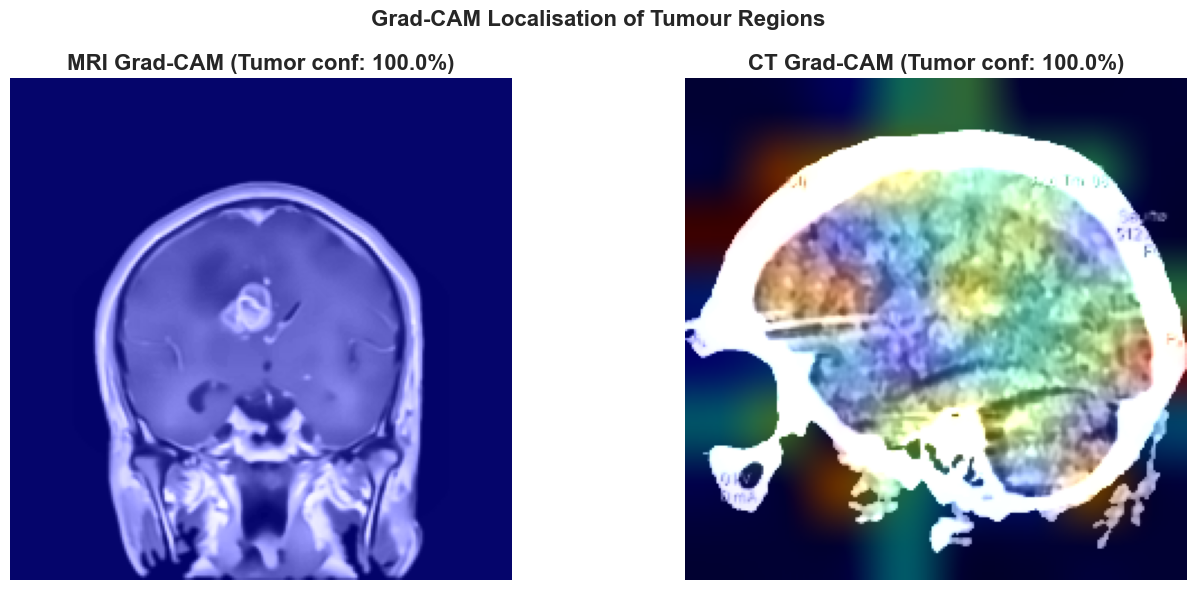

In [20]:
# ============================================================================
# GRAD-CAM FOR INTERPRETABILITY
# ============================================================================
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import os

def make_gradcam_heatmap(img_array, model, last_conv_layer, pred_index=None):
    if isinstance(last_conv_layer, str):
        last_conv_layer = model.get_layer(last_conv_layer)

    grad_model = tf.keras.models.Model(
        model.inputs, 
        [last_conv_layer.output, model.output]
    )
    
    with tf.GradientTape() as tape:
        last_conv_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, last_conv_output)
    
    reduce_axes = tuple(range(len(grads.shape) - 1)) 
    pooled_grads = tf.reduce_mean(grads, axis=reduce_axes)
    
    last_conv_output = last_conv_output[0]
    heatmap = last_conv_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

def display_gradcam(img_path, heatmap, alpha=0.4):
    img = np.load(img_path)
    base_img = img[:,:,0]  # first channel (structural)
    base_img = np.uint8(255 * (base_img - base_img.min()) / (base_img.max() - base_img.min() + 1e-8))
    base_img = cv2.cvtColor(base_img, cv2.COLOR_GRAY2RGB)

    heatmap = np.uint8(255 * heatmap)
    jet = cm.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]
    jet_heatmap = tf.keras.preprocessing.image.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((base_img.shape[1], base_img.shape[0]))
    jet_heatmap = tf.keras.preprocessing.image.img_to_array(jet_heatmap)

    superimposed = jet_heatmap * alpha + base_img
    superimposed = np.clip(superimposed, 0, 255).astype(np.uint8)
    return superimposed

def visualize_gradcam_for_sample(mri_path, ct_path, mri_model, ct_model, mri_layer, ct_layer):
    mri_img = np.load(mri_path).astype(np.float32)
    ct_img = np.load(ct_path).astype(np.float32)
    
    # Resize using your CONFIG shapes (ensure CONFIG is defined or replace with actual tuples)
    if mri_img.shape[:2] != CONFIG['FUSION_INPUT_SHAPE_MRI'][:2]:
        mri_img = tf.image.resize(mri_img, CONFIG['FUSION_INPUT_SHAPE_MRI'][:2]).numpy()
    if ct_img.shape[:2] != CONFIG['FUSION_INPUT_SHAPE_CT'][:2]:
        ct_img = tf.image.resize(ct_img, CONFIG['FUSION_INPUT_SHAPE_CT'][:2]).numpy()
        
    mri_img_batch = np.expand_dims(mri_img, 0)
    ct_img_batch = np.expand_dims(ct_img, 0)

    mri_pred = mri_model.predict(mri_img_batch, verbose=0)[0]
    ct_pred = ct_model.predict(ct_img_batch, verbose=0)[0]
    mri_conf = mri_pred[1]
    ct_conf = ct_pred[1]

    mri_heatmap = make_gradcam_heatmap(mri_img_batch, mri_model, mri_layer, pred_index=1)
    ct_heatmap = make_gradcam_heatmap(ct_img_batch, ct_model, ct_layer, pred_index=1)

    # Reshape CT heatmap from (64,) to (8, 8) 
    if ct_heatmap.ndim == 1:
        ct_heatmap = ct_heatmap.reshape((8, 8))

    mri_cam = display_gradcam(mri_path, mri_heatmap)
    ct_cam = display_gradcam(ct_path, ct_heatmap)

    fig, axes = plt.subplots(1, 2, figsize=(14,6))
    axes[0].imshow(mri_cam)
    axes[0].set_title(f"MRI Grad-CAM (Tumor conf: {mri_conf:.1%})", fontweight='bold')
    axes[0].axis('off')
    axes[1].imshow(ct_cam)
    axes[1].set_title(f"CT Grad-CAM (Tumor conf: {ct_conf:.1%})", fontweight='bold')
    axes[1].axis('off')
    plt.suptitle("Grad-CAM Localisation of Tumour Regions", fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(CONFIG['FIGURE_PATH'], 'gradcam_example.png'), dpi=300)
    plt.show()

# --- Execution Logic ---
print("[Grad-CAM] Searching for a tumor sample in the test set...")
tumor_idx = None

# We use the test_gen variable returned from the first cell
for idx, (_, _, label, _) in enumerate(test_gen.pairs):
    if label == 1:
        tumor_idx = idx
        break

if tumor_idx is not None:
    mri_path, ct_path, _, _ = test_gen.pairs[tumor_idx]
    
    # Define layers (Update these strings if your layer names differ)
    mri_last_conv = 'conv2d_164'   
    ct_conv_layer = ct_model.get_layer('time_distributed_encoder')

    print(f"[Grad-CAM] Processing sample {tumor_idx}...")
    visualize_gradcam_for_sample(
        mri_path, 
        ct_path, 
        mri_stage1,  # Passed from Cell 1
        ct_model,    # Passed from Cell 1
        mri_last_conv, 
        ct_conv_layer
    )
else:
    print("No tumor sample found in test set for Grad-CAM.")